In [1]:
import numpy as np
import matplotlib.pyplot as plt
from misc import Polynom
from lineq.gauss import gauss_elimination
from misc.polynom import merge_polynoms


In [2]:
xs = np.array([1., 2., 3., 4.])
ys = np.array([0., 2., 1., 3.])

In [3]:
def create_base_polynom(degree):
    degree = degree
    coeffs = [0] * (degree + 1)
    coeffs[-1] = 1
    base_polynom = Polynom(coeffs)
    return base_polynom

In [5]:
def create_linear_equation(xs, base_polynoms):
    return np.array([base_polynom(xs) for base_polynom in base_polynoms]).T

In [6]:
base_polynoms = [create_base_polynom(i) for i in range(len(xs))]
A = create_linear_equation(xs, base_polynoms)
merge_coeffs = gauss_elimination(A, ys)

In [7]:
interpolating_polynom = merge_polynoms(base_polynoms, merge_coeffs)
interpolating_polynom

Polynomial: f(x) = -11.0 + 17.5x - 7.5x^2 + x^3

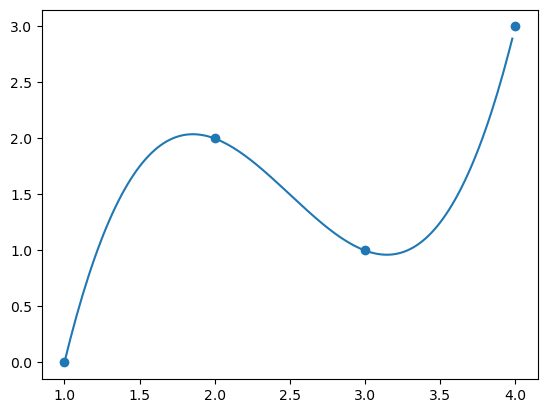

In [8]:
ts = np.arange(xs[0], xs[-1], 0.02)
plt.scatter(xs, ys)
plt.plot(ts, interpolating_polynom(ts))